#Понижение размерности. Поиск аномалий

- выполнила: Ахматова Ульяна, ИТХ-2-2021
- используемый датасет: Hearts Desease (https://archive.ics.uci.edu/dataset/45/heart+disease)

задание:
- изучить теорию
- реализовать рассмотренные методы на своем датасете (признаков должно быть более 5)
- визуализировать результаты

In [1]:
pip install ucimlrepo

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

In [3]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print(heart_disease.variables)

display(X)

        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


In [4]:
df = pd.concat([X, y], axis=1)
df = df.dropna()

In [5]:
df = pd.concat([df] * 100, ignore_index=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29695,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0,1
29696,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
29697,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
29698,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3


In [6]:
X = df.drop(['num'], axis=1)
df['num'] = df['num'].replace({2: 1, 3: 1, 4: 1})
y = df['num']
vals = sorted(df['num'].unique())

In [7]:
cols_for_clusters = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

In [8]:
df['num'].value_counts()

,count
num,
0,16000
1,13700


In [9]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)
df = pd.concat([X, y], axis=1)

In [10]:
df['num'].value_counts()

,count
num,
0,16000
1,16000


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
normalized_data = scaler_minmax.fit_transform(df)

# Создаем DataFrame из нормализованных данных
df_norm = pd.DataFrame(normalized_data, columns=df.columns)
df_norm

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0.708333,1.0,0.000000,0.481132,0.244292,1.0,1.0,0.603053,0.0,0.370968,1.0,0.000000,0.75,0.0
1,0.791667,1.0,1.000000,0.622642,0.365297,0.0,1.0,0.282443,1.0,0.241935,0.5,1.000000,0.00,1.0
2,0.791667,1.0,1.000000,0.245283,0.235160,0.0,1.0,0.442748,1.0,0.419355,0.5,0.666667,1.00,1.0
3,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.0,0.885496,0.0,0.564516,1.0,0.000000,0.00,0.0
4,0.250000,0.0,0.333333,0.339623,0.178082,0.0,1.0,0.770992,0.0,0.225806,0.0,0.000000,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31995,0.437500,1.0,1.000000,0.528302,0.267123,0.0,1.0,0.435115,0.0,0.419355,0.5,0.000000,1.00,1.0
31996,0.312500,1.0,1.000000,0.245283,0.098174,0.0,0.0,0.557252,1.0,0.451613,1.0,0.000000,0.75,1.0
31997,0.645833,1.0,0.666667,0.433962,0.134703,0.0,1.0,0.641221,0.0,0.483871,0.5,0.000000,0.00,1.0
31998,0.687500,0.0,1.000000,0.528302,0.269406,0.0,0.0,0.633588,1.0,0.225806,0.5,0.000000,0.00,1.0


In [12]:
X_norm = df_norm.drop(['num'], axis=1)
y_norm = df_norm['num']

##Метод главных компонентов (Principal Component Analysis, PCA)
 для уменьшения размерности больших наборов данных путем преобразования большого набора переменных в меньший, который по-прежнему содержит большую часть информации о большом наборе

 находит наилучшие линейные комбинации исходных переменных, так что дисперсия или разброс по новой переменной максимальны

In [64]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA

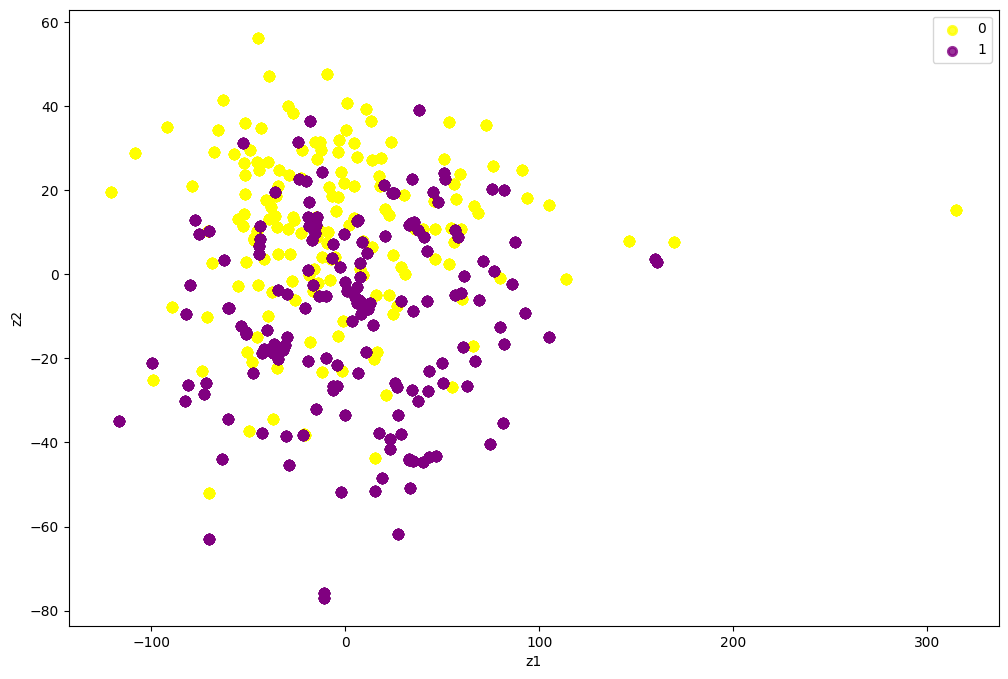

In [75]:
#без нормализации

pca = PCA(n_components=2)
X_new = pca.fit(X).transform(X)


plt.figure(figsize=(12,8))
colors = ['yellow', 'purple']
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [76]:
pca.explained_variance_ratio_

array([0.73972968, 0.15726005])

первые главные компоненты сохраняют 74% дисперсии, вторые главные - 15% дисперсии

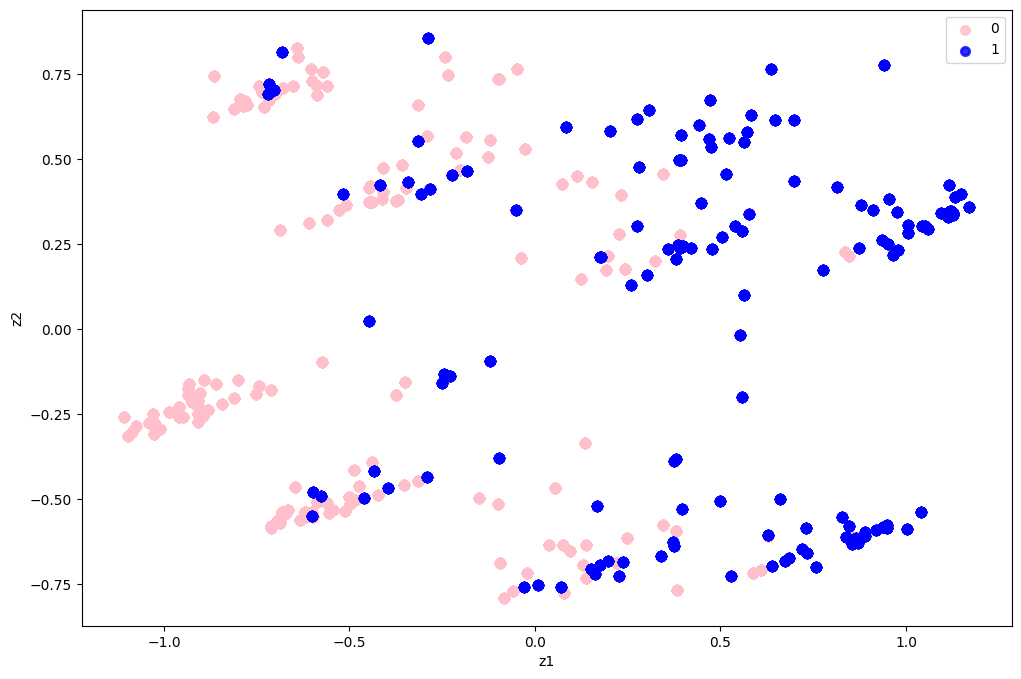

In [ ]:
#с нормализованными данными

pca = PCA(n_components=2)
X_n = pca.fit(X_norm).transform(X_norm)


plt.figure(figsize=(12,8))
colors = ['pink', 'blue']
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_n[y_norm == i, 0], X_n[y_norm == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [ ]:
pca.explained_variance_ratio_

array([0.27548695, 0.16945487])

##Независисый анализ компонентов (Independent Component Analysis, ICA)
метод снижения размерности, аналогичный PCA в том смысле, что он берет набор признаков и создает другой набор, который полезен в некотором роде

Мотивация ICA заключается в том, чтобы взять исходный набор признаков и попытаться определить те из них, которые вносят независимый вклад в набор данных, другими словами, те, которые имеют наименьшую корреляцию с другими признаками. Поэтому он изолирует эти наиболее важные компоненты. Эта проблема называется слепой изоляцией источника.

In [ ]:
from sklearn.decomposition import FastICA

fast_ica = FastICA(n_components=2)
X_new = fast_ica.fit_transform(X)

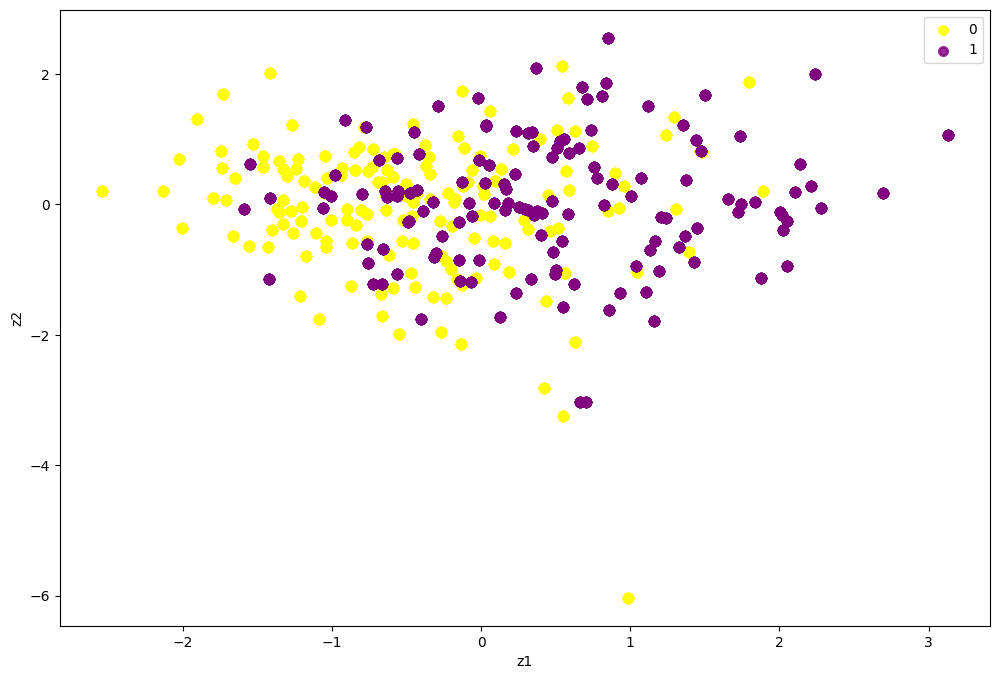

In [ ]:
plt.figure(figsize=(12,8))
colors = ['yellow', 'purple']
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [ ]:
fast_ica = FastICA(n_components=2)
X_n = fast_ica.fit_transform(X_norm)

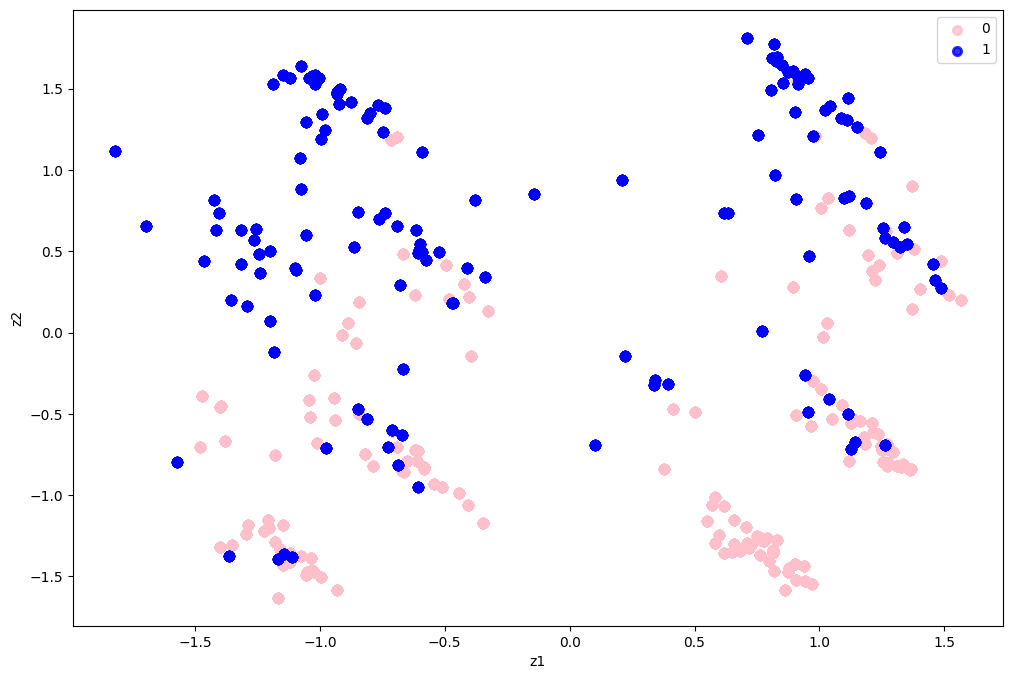

In [ ]:
plt.figure(figsize=(12,8))
colors = ['pink', 'blue']
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_n[y_norm == i, 0], X_n[y_norm == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

##Kernel PCA



In [27]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X.head(5000))

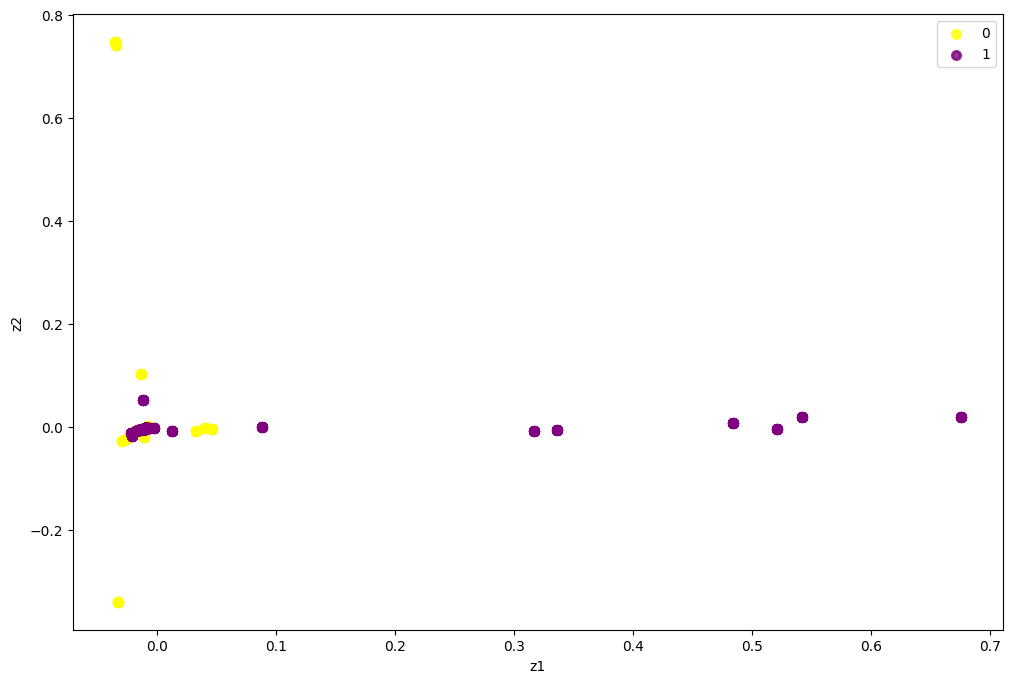

In [28]:
plt.figure(figsize=(12,8))
colors = ['yellow', 'purple']
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_new[y.head(5000) == i, 0], X_new[y.head(5000) == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

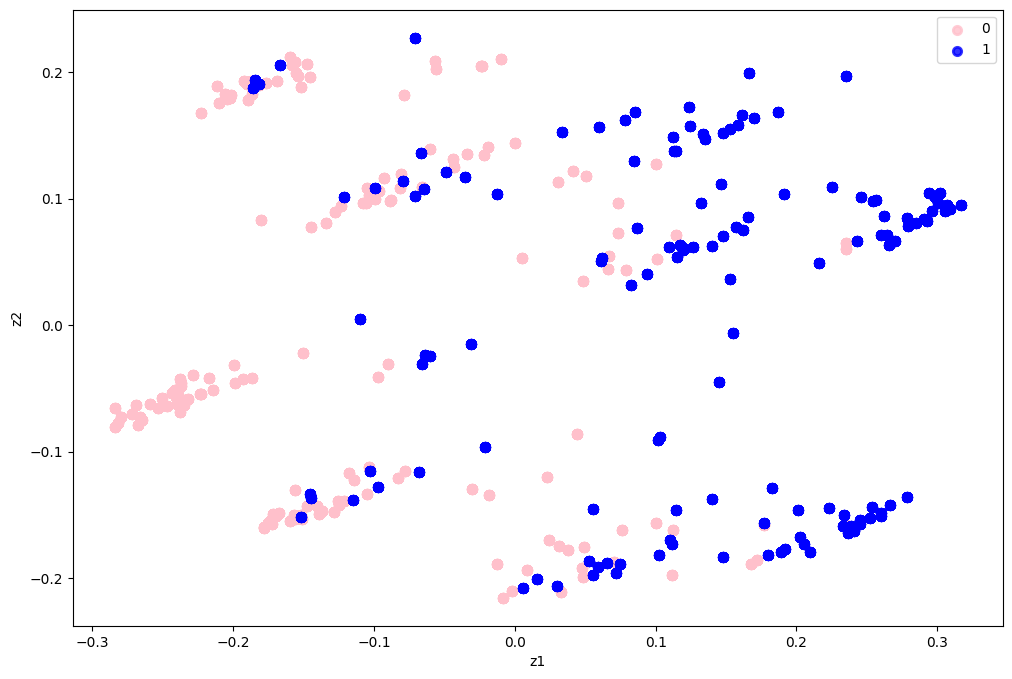

In [30]:
X_n = rbf_pca.fit_transform(X_norm.head(5000))
plt.figure(figsize=(12,8))
colors = ['pink', 'blue']
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_n[y_norm.head(5000) == i, 0], X_n[y_norm.head(5000) == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

##tSNE

метод, который использует поэтапный итерационный подход для низкоразмерного представления исходных данных с сохранением информации об их локальном соседстве

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_new = tsne.fit_transform(X)

In [ ]:
# Вывод результатов
print('Initial Shape of X: ', X.shape)
print('New Shape of X: ', X_new.shape)
print('Kullback-Leibler divergence after optimization: ', tsne.kl_divergence_)
print('No. of iterations: ', tsne.n_iter_)
#print('Embedding vectors: ', tsne.embedding_)

Initial Shape of X:  (32000, 13)
New Shape of X:  (32000, 2)
Kullback-Leibler divergence after optimization:  -3.5728280544281006
No. of iterations:  999


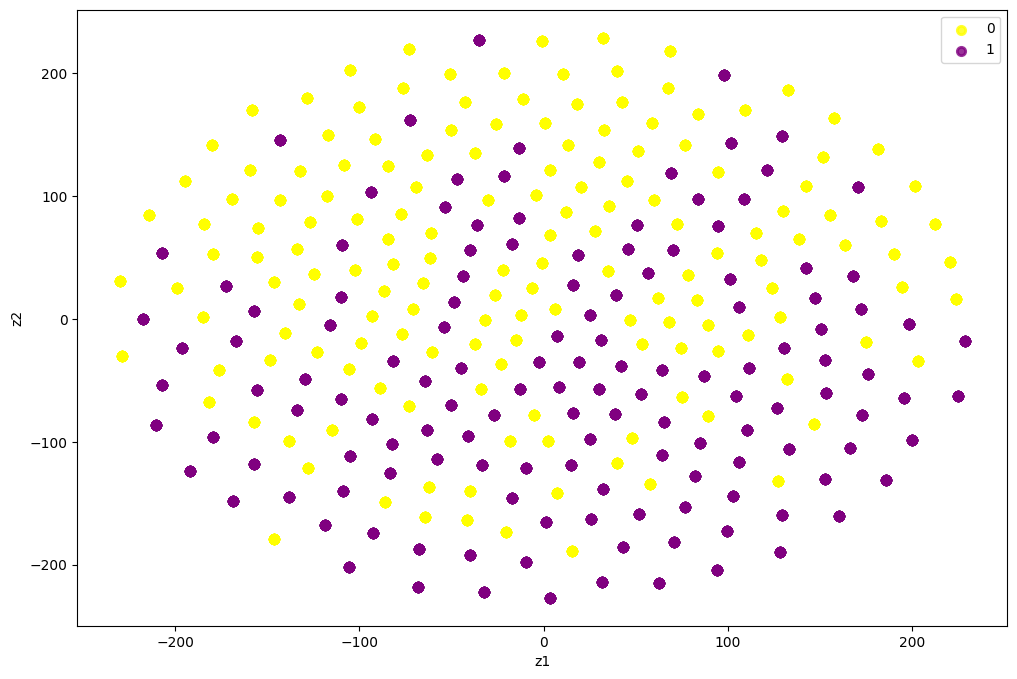

In [ ]:
plt.figure(figsize=(12,8))
colors = ['yellow', 'purple']
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Initial Shape of X:  (32000, 13)
New Shape of X:  (32000, 2)
Kullback-Leibler divergence after optimization:  -3.5728254318237305
No. of iterations:  999


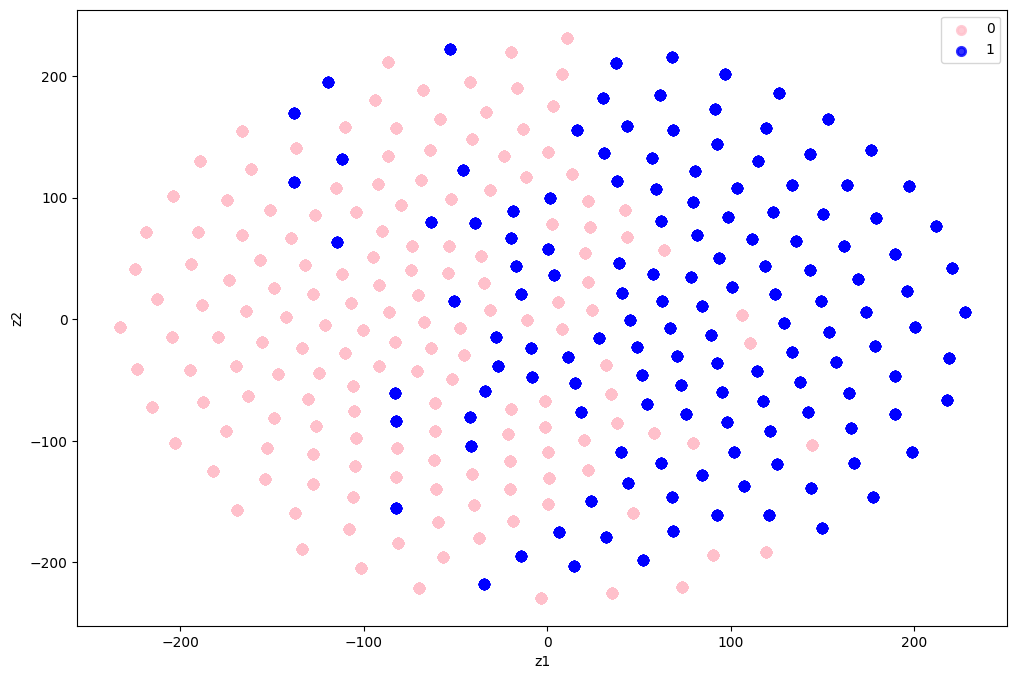

In [ ]:
X_n = tsne.fit_transform(X_norm)
print('Initial Shape of X: ', X_norm.shape)
print('New Shape of X: ', X_n.shape)
print('Kullback-Leibler divergence after optimization: ', tsne.kl_divergence_)
print('No. of iterations: ', tsne.n_iter_)

plt.figure(figsize=(12,8))
colors = ['pink', 'blue']
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_n[y_norm == i, 0], X_n[y_norm == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

##DBSCAN для кластеризации

In [13]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import v_measure_score

In [30]:
# 32 65
dbscan_cluster1 = DBSCAN(eps = 32, min_samples = 65)
X_new = dbscan_cluster1.fit(X.head(5000))

# Number of Clusters
labels=dbscan_cluster1.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster1.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y.head(5000), labels))

Estimated no. of clusters: 2
Estimated no. of noise points: 118
v_measure = 0.00138723822003195


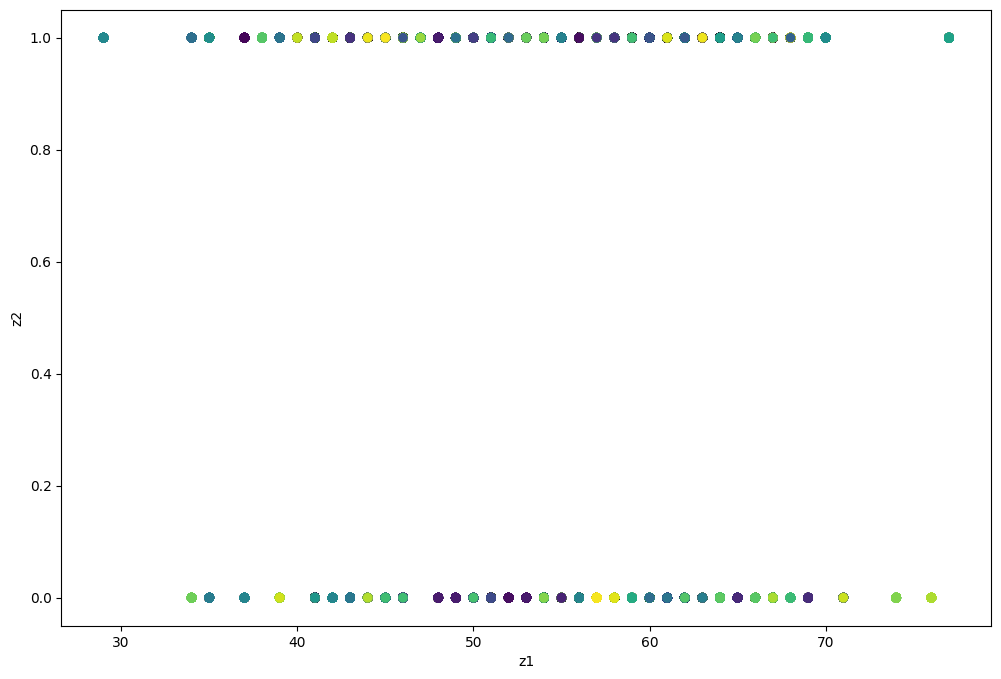

In [29]:
plt.figure(figsize=(12,8))
lw = 2

plt.scatter(
        X[cols_for_clusters[0]], X[cols_for_clusters[1]], c=dbscan_cluster1.labels_
    )

plt.xlabel("z1")
plt.ylabel("z2")

plt.show()

In [46]:
from sklearn.neighbors import NearestNeighbors

min_samples = 57

knn = NearestNeighbors(n_neighbors = min_samples, metric = 'l2')
knn.fit(X)

dists, inds = knn.kneighbors(X)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()

In [51]:
import sklearn
#возможные метрики расстояния
sklearn.metrics.pairwise.distance_metrics()

{'cityblock': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'cosine': <function sklearn.metrics.pairwise.cosine_distances(X, Y=None)>,
 'euclidean': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'haversine': <function sklearn.metrics.pairwise.haversine_distances(X, Y=None)>,
 'l2': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'l1': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'manhattan': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'precomputed': None,
 'nan_euclidean': <function sklearn.metrics.pairwise.nan_euclidean_distances(X, Y=None, *, squared=False, missing_values=nan, copy=True)>}

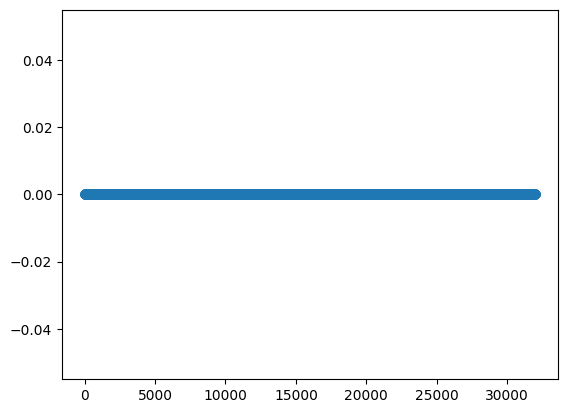

In [52]:
plt.scatter(x = range(len(dists_ar)), y=dists_ar)
plt.show()

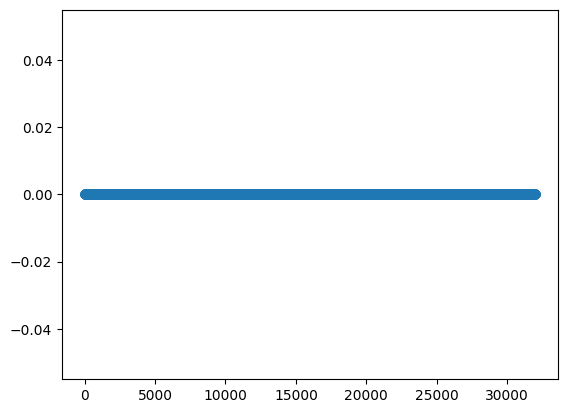

In [53]:
knn.fit(X_norm)

dists, inds = knn.kneighbors(X_norm)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()
plt.scatter(x = range(len(dists_ar)), y=dists_ar)
plt.show()

##DBSCAN для определения выбросов

In [35]:
dbscan = DBSCAN(eps = 0.5, min_samples = min_samples)

In [36]:
pred = dbscan.fit_predict(X)

In [37]:
# Number of Clusters
labels=dbscan.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 297
Estimated no. of noise points: 0
v_measure = 0.21716563589247723


In [38]:
# у аномалий - класс -1, ищем все номера строк с таким классом, потом отбираем эти строки из начального набора данных

anom_index = [i for i in range(len(pred)) if pred[i] == -1]
values = X.loc[anom_index]

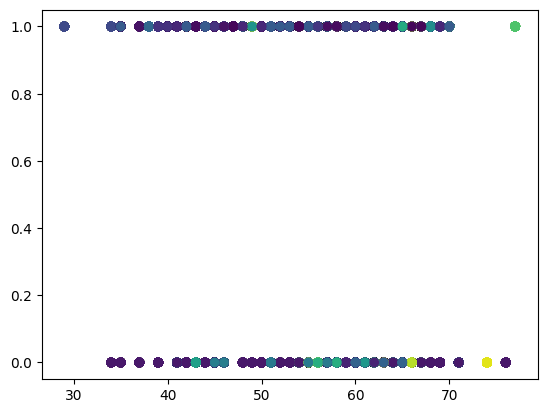

In [39]:
plt.scatter( X[cols_for_clusters[0]], X[cols_for_clusters[1]],c=dbscan_cluster1.labels_)
plt.scatter(values[cols_for_clusters[0]], values[cols_for_clusters[1]], color='r')
plt.show()

In [ ]:
pred = dbscan.fit_predict(X_norm)

In [ ]:
# Number of Clusters
labels=dbscan.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y_norm, labels))

Estimated no. of clusters: 135
Estimated no. of noise points: 0
v_measure = 0.19508972798556456


In [ ]:
# у аномалий - класс -1, ищем все номера строк с таким классом, потом отбираем эти строки из начального набора данных

anom_index = [i for i in range(len(pred)) if pred[i] == -1]
values = X_norm.loc[anom_index]

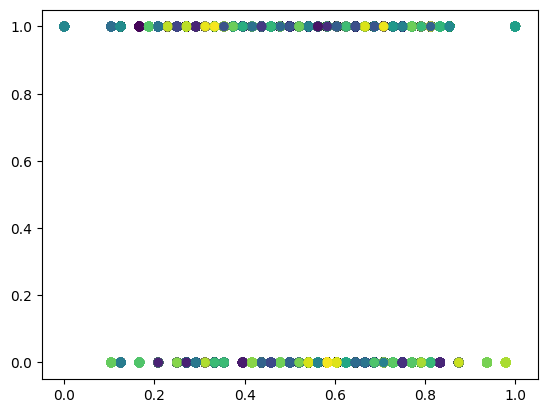

In [ ]:
plt.scatter( X_norm[cols_for_clusters[0]], X_norm[cols_for_clusters[1]],c=dbscan_cluster1.labels_)
plt.scatter(values[cols_for_clusters[0]], values[cols_for_clusters[1]], color='r')
plt.show()